<a href="https://colab.research.google.com/github/BhavyaJain7/Hybrid-Neural-Retrieval/blob/main/Hybrid_Neural_Retrieval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip -q install datasets sentence-transformers faiss-cpu rank-bm25 scikit-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 90.8 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
from datasets import load_dataset
from tqdm import tqdm

# libraries for retrieval of data
from rank_bm25 import BM25Okapi
from sklearn.feature_extraction.text import TfidfVectorizer

In [4]:
dataset = load_dataset("ms_marco", "v1.1")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

v1.1/validation-00000-of-00001.parquet:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

v1.1/train-00000-of-00001.parquet:   0%|          | 0.00/175M [00:00<?, ?B/s]

v1.1/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/10047 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/82326 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/9650 [00:00<?, ? examples/s]

In [5]:
dataset

DatasetDict({
    validation: Dataset({
        features: ['answers', 'passages', 'query', 'query_id', 'query_type', 'wellFormedAnswers'],
        num_rows: 10047
    })
    train: Dataset({
        features: ['answers', 'passages', 'query', 'query_id', 'query_type', 'wellFormedAnswers'],
        num_rows: 82326
    })
    test: Dataset({
        features: ['answers', 'passages', 'query', 'query_id', 'query_type', 'wellFormedAnswers'],
        num_rows: 9650
    })
})

MS Macro dataset is split into fixed benchmark splits used for the research purposes as -:
Train : ~808,731 queries
Validation : ~101,093 queries
Test : ~100,000 queries
Ratio : 80-10-10

In [6]:
queries = []
corpus = []
qrels = []

for item in dataset["validation"]:

    query = item["query"]
    passages = item["passages"]["passage_text"]
    labels = item["passages"]["is_selected"]

    queries.append(query)

    for p, l in zip(passages, labels):
        corpus.append(p)
        qrels.append(l)

In [7]:
queries_df = pd.DataFrame({
    "query_id": range(len(queries)),
    "query": queries
})

corpus_df = pd.DataFrame({
    "doc_id": range(len(corpus)),
    "text": corpus
})

labels_df = pd.DataFrame({
    "doc_id": range(len(qrels)),
    "relevant": qrels
})

In [8]:
print("Number of queries:", len(queries_df))
print("Number of documents:", len(corpus_df))
print("Relevant passages:", labels_df['relevant'].sum())

Number of queries: 10047
Number of documents: 82360
Relevant passages: 10783


In [9]:
tokenized_corpus = [doc.split(" ") for doc in corpus_df["text"]]

tokenized courpus is created to be utilized for BM25 retrieval

In [10]:
tfidf_vectorizer = TfidfVectorizer(stop_words="english", max_features=50000)

tfidf_matrix = tfidf_vectorizer.fit_transform(corpus_df["text"])

TF-IDF corpus

In [11]:
queries_df.to_csv("queries.csv", index=False)
corpus_df.to_csv("corpus.csv", index=False)
labels_df.to_csv("labels.csv", index=False)

In [12]:
#converting the dataset into standard IR format
corpus = {}
queries = {}
qrels = {}


doc_id = 0

for q_id, item in enumerate(dataset["validation"]):

    queries[q_id] = item["query"]

    passages = item["passages"]["passage_text"]
    labels = item["passages"]["is_selected"]

    for p, l in zip(passages, labels):

        corpus[doc_id] = p

        if l == 1:
            if q_id not in qrels:
                qrels[q_id] = []
            qrels[q_id].append(doc_id)

        doc_id += 1

In [13]:
print("Total queries:", len(queries))
print("Total documents:", len(corpus))
print("Queries with relevant docs:", len(qrels))

Total queries: 10047
Total documents: 82360
Queries with relevant docs: 9706


In [14]:
# TF-IDF Retrieval

import time
import numpy as np
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("Preparing corpus and queries...")

doc_ids = list(corpus.keys())
documents = list(corpus.values())

query_ids = list(queries.keys())
query_texts = list(queries.values())

print("Total Documents:", len(documents))
print("Total Queries:", len(query_texts))


# Build TF-IDF index
print("\nBuilding TF-IDF index...")

tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=50000
)

doc_vectors = tfidf_vectorizer.fit_transform(documents)

print("TF-IDF Matrix Shape:", doc_vectors.shape)


# Retrieval function
def retrieve_tfidf(query, top_k=10):
    query_vec = tfidf_vectorizer.transform([query])
    similarities = cosine_similarity(query_vec, doc_vectors).flatten()
    top_indices = similarities.argsort()[-top_k:][::-1]
    return [doc_ids[i] for i in top_indices]

print("\nRunning retrieval...")

results = {}
top_k = 10
start_time = time.time()

for q_id, query in tqdm(queries.items()):
    retrieved_docs = retrieve_tfidf(query, top_k)
    results[q_id] = retrieved_docs

end_time = time.time()
latency = (end_time - start_time) / len(queries)

# Evaluation metrics
def recall_at_k(results, qrels, k=10):
    recalls = []
    for q_id, retrieved in results.items():
        if q_id not in qrels:
            continue
        relevant_docs = set(qrels[q_id])
        retrieved_k = set(retrieved[:k])
        recall = len(relevant_docs & retrieved_k) / len(relevant_docs)
        recalls.append(recall)
    return np.mean(recalls)

def mrr_at_k(results, qrels, k=10):
    mrr_scores = []
    for q_id, retrieved in results.items():
        if q_id not in qrels:
            continue
        relevant_docs = set(qrels[q_id])
        score = 0
        for rank, doc_id in enumerate(retrieved[:k], start=1):
            if doc_id in relevant_docs:
                score = 1 / rank
                break
        mrr_scores.append(score)
    return np.mean(mrr_scores)

print("\nEvaluating results...")

recall = recall_at_k(results, qrels, k=10)
mrr = mrr_at_k(results, qrels, k=10)

print("\n===== TF-IDF RESULTS =====")

print("Recall@10:", recall)
print("MRR@10:", mrr)
print("Average Query Latency:", latency, "seconds")

Preparing corpus and queries...
Total Documents: 82360
Total Queries: 10047

Building TF-IDF index...
TF-IDF Matrix Shape: (82360, 50000)

Running retrieval...


100%|██████████| 10047/10047 [09:19<00:00, 17.94it/s]



Evaluating results...

===== TF-IDF RESULTS =====
Recall@10: 0.6493543512603888
MRR@10: 0.3043432879024266
Average Query Latency: 0.05573095138172397 seconds


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

##TF-IDF Workflow
1. Conversion of document corpus (dataset) into numerical vectors using TF-IDF vectorization.
2. Similarly, user Query will be converted into TF-IDF vector
3. Similarities are computed using cosine similarity to identify most relevant document.
4. System retrieves top 10 most relevant documents for each query based on these scores.
5. Performance is evaluated using metrics like Recall@10, Mean Reciprocal Rank @10, Average Latency.



In [15]:
# BM25 Retrieval

import time
import numpy as np
from tqdm import tqdm
from rank_bm25 import BM25Okapi


print("Preparing corpus...")

doc_ids = list(corpus.keys())
documents = list(corpus.values())

query_ids = list(queries.keys())
query_texts = list(queries.values())

print("Total Documents:", len(documents))
print("Total Queries:", len(query_texts))


# Tokenize the corpus
tokenized_corpus = [doc.lower().split() for doc in documents]

print("\nBuilding BM25 index...")

bm25 = BM25Okapi(tokenized_corpus)


# Retrieval function
def retrieve_bm25(query, top_k=10):

    tokenized_query = query.lower().split()

    scores = bm25.get_scores(tokenized_query)

    top_indices = np.argsort(scores)[-top_k:][::-1]

    return [doc_ids[i] for i in top_indices]


# Run retrieval
print("\nRunning BM25 retrieval...")

results = {}
top_k = 10

start_time = time.time()

for q_id, query in tqdm(queries.items()):

    retrieved_docs = retrieve_bm25(query, top_k)

    results[q_id] = retrieved_docs

end_time = time.time()

latency = (end_time - start_time) / len(queries)


# Evaluation metrics

def recall_at_k(results, qrels, k=10):

    recalls = []

    for q_id, retrieved in results.items():

        if q_id not in qrels:
            continue

        relevant_docs = set(qrels[q_id])
        retrieved_k = set(retrieved[:k])

        recall = len(relevant_docs & retrieved_k) / len(relevant_docs)

        recalls.append(recall)

    return np.mean(recalls)


def mrr_at_k(results, qrels, k=10):

    mrr_scores = []

    for q_id, retrieved in results.items():

        if q_id not in qrels:
            continue

        relevant_docs = set(qrels[q_id])

        score = 0

        for rank, doc_id in enumerate(retrieved[:k], start=1):

            if doc_id in relevant_docs:
                score = 1 / rank
                break

        mrr_scores.append(score)

    return np.mean(mrr_scores)


print("\nEvaluating BM25 results...")

recall = recall_at_k(results, qrels, k=10)
mrr = mrr_at_k(results, qrels, k=10)


print("\n===== BM25 RESULTS =====")

print("Recall@10:", recall)
print("MRR@10:", mrr)
print("Average Query Latency:", latency, "seconds")

Preparing corpus...
Total Documents: 82360
Total Queries: 10047

Building BM25 index...

Running BM25 retrieval...


100%|██████████| 10047/10047 [34:45<00:00,  4.82it/s]


Evaluating BM25 results...

===== BM25 RESULTS =====
Recall@10: 0.6545744900061818
MRR@10: 0.3328086619633086
Average Query Latency: 0.2075325027204597 seconds


#BM25 Retrieval
1. Dataset/document corpus is prepared and tokenized.
2. BM25 index is built using this corpus to calculate the term based relevance scores.
3. Similarly, the query is also tokenized and compared against indexed documents using the same BM25 index function
4. System then ranks the top 10 most relevant documnets using relevance scores.
5. Metrics used - Recall@10, MRR@10 and Average Latency

In [17]:
# Dense Retrieval

import time
import numpy as np
from tqdm import tqdm
import torch
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print("Checking GPU availability...")
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device being used:", device)
print("\nLoading embedding model...")
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=device)

doc_ids = list(corpus.keys())
documents = list(corpus.values())

query_items = list(queries.items())[:1000]

print("\nDocuments:", len(documents))
print("Queries used for evaluation:", len(query_items))

print("\nEncoding documents (GPU)...")

doc_embeddings = model.encode(
    documents,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Document embedding shape:", doc_embeddings.shape)

# Retrieval function
def retrieve_dense(query, top_k=10):
    query_embedding = model.encode([query], convert_to_numpy=True)
    similarities = cosine_similarity(query_embedding, doc_embeddings).flatten()
    top_indices = similarities.argsort()[-top_k:][::-1]
    return [doc_ids[i] for i in top_indices]

# Run retrieval
print("\nRunning dense retrieval...")

results = {}
top_k = 10

start_time = time.time()

for q_id, query in tqdm(query_items):
    retrieved_docs = retrieve_dense(query, top_k)
    results[q_id] = retrieved_docs

end_time = time.time()
latency = (end_time - start_time) / len(query_items)

# Evaluation metrics
def recall_at_k(results, qrels, k=10):
    recalls = []
    for q_id, retrieved in results.items():
        if q_id not in qrels:
            continue
        relevant_docs = set(qrels[q_id])
        retrieved_k = set(retrieved[:k])
        recall = len(relevant_docs & retrieved_k) / len(relevant_docs)
        recalls.append(recall)
    return np.mean(recalls)

def mrr_at_k(results, qrels, k=10):
    mrr_scores = []
    for q_id, retrieved in results.items():
        if q_id not in qrels:
            continue
        relevant_docs = set(qrels[q_id])
        score = 0
        for rank, doc_id in enumerate(retrieved[:k], start=1):
            if doc_id in relevant_docs:
                score = 1 / rank
                break
        mrr_scores.append(score)
    return np.mean(mrr_scores)

print("\nEvaluating dense retrieval...")
recall = recall_at_k(results, qrels, k=10)
mrr = mrr_at_k(results, qrels, k=10)
print("\n===== DENSE RETRIEVAL RESULTS=====")
print("Recall@10:", recall)
print("MRR@10:", mrr)
print("Average Query Latency:", latency, "seconds")

Checking GPU availability...
Device being used: cuda

Loading embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Documents: 82360
Queries used for evaluation: 1000

Encoding documents (GPU)...


Batches:   0%|          | 0/644 [00:00<?, ?it/s]

Document embedding shape: (82360, 384)

Running dense retrieval...


100%|██████████| 1000/1000 [02:44<00:00,  6.08it/s]


Evaluating dense retrieval...

===== DENSE RETRIEVAL RESULTS (1000 QUERIES) =====
Recall@10: 0.8933126508100654
MRR@10: 0.5027892680684821
Average Query Latency: 0.16440525960922242 seconds


#Dense Retrieval
1. Both documents and queries are converted into semantic vector embeddings using pre-trained Language model.
2. The document corpus is encoded into numerical vectors that capture the semantic meaning of the text.
3. Document embeddings are then stored in memory.
4. Same happens with a query, when issued.
5. Cosine similarity is used to retrieve the Top-K most similar documents.
6. Finally, the retrieved results are evaluated using metrics such as Recall@10, MRR@10, and average query latency.

In [19]:
# FAISS Vector Search on Dense Embeddings

import time
import numpy as np
from tqdm import tqdm
import torch
import faiss
from sentence_transformers import SentenceTransformer

# Check GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Embedding device:", device)

# Load embedding model
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=device)

# Prepare corpus
doc_ids = list(corpus.keys())
documents = list(corpus.values())

# limit to 1000 queries
query_items = list(queries.items())[:1000]

print("Total documents:", len(documents))
print("Queries used:", len(query_items))

# Generate document embeddings (GPU)
print("\nEncoding documents...")

doc_embeddings = model.encode(
    documents,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Embedding shape:", doc_embeddings.shape)

# Build FAISS index (CPU)
dim = doc_embeddings.shape[1]

print("\nBuilding FAISS index...")

index = faiss.IndexFlatL2(dim)
index.add(doc_embeddings)

print("Vectors indexed:", index.ntotal)

# Retrieval
print("\nRunning FAISS retrieval...")

results = {}
top_k = 10
start_time = time.time()

for q_id, query in tqdm(query_items):
    query_embedding = model.encode([query], convert_to_numpy=True)
    distances, indices = index.search(query_embedding, top_k)
    retrieved_docs = [doc_ids[i] for i in indices[0]]
    results[q_id] = retrieved_docs
end_time = time.time()
latency = (end_time - start_time) / len(query_items)

# Evaluation metrics
def recall_at_k(results, qrels, k=10):
    recalls = []
    for q_id, retrieved in results.items():
        if q_id not in qrels:
            continue
        relevant_docs = set(qrels[q_id])
        retrieved_k = set(retrieved[:k])
        recall = len(relevant_docs & retrieved_k) / len(relevant_docs)
        recalls.append(recall)
    return np.mean(recalls)

def mrr_at_k(results, qrels, k=10):
    mrr_scores = []
    for q_id, retrieved in results.items():
        if q_id not in qrels:
            continue
        relevant_docs = set(qrels[q_id])
        score = 0
        for rank, doc_id in enumerate(retrieved[:k], start=1):
            if doc_id in relevant_docs:
                score = 1 / rank
                break
        mrr_scores.append(score)
    return np.mean(mrr_scores)

# Compute metrics
recall = recall_at_k(results, qrels, k=10)
mrr = mrr_at_k(results, qrels, k=10)

print("\n===== FAISS DENSE RETRIEVAL RESULTS =====")

print("Recall@10:", recall)
print("MRR@10:", mrr)
print("Average Query Latency:", latency, "seconds")

Embedding device: cuda


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total documents: 82360
Queries used: 1000

Encoding documents...


Batches:   0%|          | 0/644 [00:00<?, ?it/s]

Embedding shape: (82360, 384)

Building FAISS index...
Vectors indexed: 82360

Running FAISS retrieval...


100%|██████████| 1000/1000 [00:22<00:00, 44.74it/s]


===== FAISS DENSE RETRIEVAL RESULTS =====
Recall@10: 0.8943467769734573
MRR@10: 0.5040560726186373
Average Query Latency: 0.022356607913970948 seconds


#Dense Retrieval with FAISS
1. Document Embeddings are generated and stored in a FAISS vector index.
2. FAISS performs a fast nearest neighbor search to retrieve the most similar vectors.
3. Query, upon submission, is encoded into embedding and searched against the FAISS index to obtain top-K closest document vectors.
4. Corresponding documents are returned.
5. Finally, the retrieved results are evaluated using metrics such as Recall@10, MRR@10, and average query latency.

In [20]:
#HNSW Dense Retrieval using FAISS (Hierarchical Navigable Small World)

import time
import numpy as np
from tqdm import tqdm
import faiss
import torch
from sentence_transformers import SentenceTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Embedding device:", device)

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=device)

doc_ids = list(corpus.keys())
documents = list(corpus.values())
query_items = list(queries.items())[:1000]

print("Total documents:", len(documents))
print("Queries used:", len(query_items))

print("\nEncoding documents...")

doc_embeddings = model.encode(
    documents,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True
)

dim = doc_embeddings.shape[1]
print("Embedding shape:", doc_embeddings.shape)

print("\nBuilding HNSW index...")

M = 32  # number of neighbors in graph
index = faiss.IndexHNSWFlat(dim, M)
index.hnsw.efConstruction = 200
index.add(doc_embeddings)
print("Vectors indexed:", index.ntotal)

# Retrieval
print("\nRunning HNSW retrieval...")

results = {}
top_k = 10
start_time = time.time()

for q_id, query in tqdm(query_items):
    query_embedding = model.encode([query], convert_to_numpy=True)
    distances, indices = index.search(query_embedding, top_k)
    retrieved_docs = [doc_ids[i] for i in indices[0]]
    results[q_id] = retrieved_docs

end_time = time.time()
latency = (end_time - start_time) / len(query_items)

# Evaluation Metrics
def recall_at_k(results, qrels, k=10):
    recalls = []
    for q_id, retrieved in results.items():
        if q_id not in qrels:
            continue
        relevant_docs = set(qrels[q_id])
        retrieved_k = set(retrieved[:k])
        recall = len(relevant_docs & retrieved_k) / len(relevant_docs)
        recalls.append(recall)
    return np.mean(recalls)

def mrr_at_k(results, qrels, k=10):
    mrr_scores = []
    for q_id, retrieved in results.items():
        if q_id not in qrels:
            continue
        relevant_docs = set(qrels[q_id])
        score = 0
        for rank, doc_id in enumerate(retrieved[:k], start=1):
            if doc_id in relevant_docs:
                score = 1 / rank
                break
        mrr_scores.append(score)
    return np.mean(mrr_scores)

# Compute metrics
recall = recall_at_k(results, qrels, k=10)
mrr = mrr_at_k(results, qrels, k=10)

print("\n===== HNSW DENSE RETRIEVAL RESULTS =====")

print("Recall@10:", recall)
print("MRR@10:", mrr)
print("Average Query Latency:", latency, "seconds")

Embedding device: cuda


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total documents: 82360
Queries used: 1000

Encoding documents...


Batches:   0%|          | 0/644 [00:00<?, ?it/s]

Embedding shape: (82360, 384)

Building HNSW index...
Vectors indexed: 82360

Running HNSW retrieval...


100%|██████████| 1000/1000 [00:06<00:00, 151.16it/s]


===== HNSW DENSE RETRIEVAL RESULTS =====
Recall@10: 0.8850396415029299
MRR@10: 0.4986396316541094
Average Query Latency: 0.006619054079055786 seconds


#HNSW Dense Retrieval using FAISS

2. Designed for efficient similarity search in large vector datasets
3. Organizes data points into a multi-layer graph structure, where each node (vector) is connected to its closest neighbors
4. During retrieval, it navigates the graph top-down — starting from higher layers (fewer nodes) and moving to lower layers (more detailed connections)
5. This allows it to quickly locate the most similar vectors to a given query
6. Significantly reduces search time compared to exhaustive comparisons, while maintaining high retrieval accuracy
7. Well-suited for large-scale vector search applications, such as dense information retrieval systems



In [21]:
# Neural Re-ranking using Cross Encoder

import time
import numpy as np
from tqdm import tqdm
import torch
from sentence_transformers import CrossEncoder

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Load cross-encoder model
model = CrossEncoder(
    "cross-encoder/ms-marco-MiniLM-L-6-v2",
    device=device
)

query_items = list(queries.items())[:1000]
print("Queries used:", len(query_items))

# Re-ranking
reranked_results = {}
top_k = 10
start_time = time.time()

for q_id, query in tqdm(query_items):
    if q_id not in results:
        continue
    candidate_docs = results[q_id]
    candidate_texts = [corpus[d] for d in candidate_docs]
    pairs = [[query, doc] for doc in candidate_texts]
    scores = model.predict(pairs)
    ranked_indices = np.argsort(scores)[::-1]
    reranked_docs = [candidate_docs[i] for i in ranked_indices[:top_k]]
    reranked_results[q_id] = reranked_docs
end_time = time.time()
latency = (end_time - start_time) / len(query_items)

# Evaluation
def recall_at_k(results, qrels, k=10):
    recalls = []
    for q_id, retrieved in results.items():
        if q_id not in qrels:
            continue
        relevant_docs = set(qrels[q_id])
        retrieved_k = set(retrieved[:k])
        recall = len(relevant_docs & retrieved_k) / len(relevant_docs)
        recalls.append(recall)
    return np.mean(recalls)


def mrr_at_k(results, qrels, k=10):
    mrr_scores = []
    for q_id, retrieved in results.items():
        if q_id not in qrels:
            continue
        relevant_docs = set(qrels[q_id])
        score = 0
        for rank, doc_id in enumerate(retrieved[:k], start=1):
            if doc_id in relevant_docs:
                score = 1 / rank
                break
        mrr_scores.append(score)
    return np.mean(mrr_scores)


recall = recall_at_k(reranked_results, qrels, 10)
mrr = mrr_at_k(reranked_results, qrels, 10)

print("\n===== CROSS-ENCODER RERANKING RESULTS =====")

print("Recall@10:", recall)
print("MRR@10:", mrr)
print("Average Query Latency:", latency, "seconds")

Device: cuda


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Queries used: 1000


100%|██████████| 1000/1000 [00:19<00:00, 52.44it/s]


===== CROSS-ENCODER RERANKING RESULTS =====
Recall@10: 0.8850396415029299
MRR@10: 0.5886915021092891
Average Query Latency: 0.019074259281158447 seconds


#Neural Re-ranking using Cross Encoder
1. First, an initial retrieval method like BM25, Dense Retrieval, FAISS, or HNSW is used to get a list of candidate documents for a query.
2. The top retrieved documents are selected as candidates for further processing.
3. Each candidate document is paired with the query to create query document pairs.
4. These pairs are passed to a cross-encoder model, which reads the query and document together and gives a relevance score based on how well they match.
5. The documents are re-ranked using these scores, and the results are evaluated using metrics such as Recall@10, MRR@10, and query latency to measure the improvement.


In [22]:
# Generate BM25 and Dense Retrieval Results for Hybrid Fusion

import numpy as np
from tqdm import tqdm
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

doc_ids = list(corpus.keys())
documents = list(corpus.values())
query_items = list(queries.items())[:1000]

# BM25 INDEX
tokenized_corpus = [doc.lower().split() for doc in documents]
bm25 = BM25Okapi(tokenized_corpus)

bm25_results = {}
print("\nRunning BM25 retrieval...")

for q_id, query in tqdm(query_items):
    tokenized_query = query.lower().split()
    scores = bm25.get_scores(tokenized_query)
    top_indices = np.argsort(scores)[-50:][::-1]
    bm25_results[q_id] = [doc_ids[i] for i in top_indices]

# Dense Retrieval
print("\nLoading embedding model...")
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=device)
print("\nEncoding documents...")
doc_embeddings = model.encode(
    documents,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True
)

dense_results = {}
print("\nRunning Dense retrieval...")

for q_id, query in tqdm(query_items):
    query_embedding = model.encode([query], convert_to_numpy=True)
    similarities = cosine_similarity(query_embedding, doc_embeddings).flatten()
    top_indices = similarities.argsort()[-50:][::-1]
    dense_results[q_id] = [doc_ids[i] for i in top_indices]

print("\nBM25 results stored:", len(bm25_results))
print("Dense results stored:", len(dense_results))

Device: cuda

Running BM25 retrieval...


100%|██████████| 1000/1000 [04:20<00:00,  3.83it/s]



Loading embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Encoding documents...


Batches:   0%|          | 0/644 [00:00<?, ?it/s]


Running Dense retrieval...


100%|██████████| 1000/1000 [02:51<00:00,  5.81it/s]


BM25 results stored: 1000
Dense results stored: 1000


In [24]:
# Hybrid Retrieval using Reciprocal Rank Fusion (RRF)

import numpy as np
import time
from tqdm import tqdm

query_items = list(queries.items())[:1000]
print("Queries used:", len(query_items))

# RRF Fusion Function
def reciprocal_rank_fusion(rank_lists, k=60):
    scores = {}
    for rank_list in rank_lists:
        for rank, doc_id in enumerate(rank_list):
            score = 1 / (k + rank + 1)
            if doc_id not in scores:
                scores[doc_id] = 0
            scores[doc_id] += score
    ranked_docs = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [doc for doc, _ in ranked_docs]

# Hybrid Retrieval
hybrid_results = {}
top_k = 10
start_time = time.time()

for q_id, query in tqdm(query_items):
    if q_id not in bm25_results or q_id not in dense_results:
        continue
    bm25_rank = bm25_results[q_id]
    dense_rank = dense_results[q_id]
    fused = reciprocal_rank_fusion([bm25_rank, dense_rank])
    hybrid_results[q_id] = fused[:top_k]
end_time = time.time()
latency = (end_time - start_time) / len(query_items)

# Evaluation Metrics
def recall_at_k(results, qrels, k=10):
    recalls = []
    for q_id, retrieved in results.items():
        if q_id not in qrels:
            continue
        relevant_docs = set(qrels[q_id])
        retrieved_k = set(retrieved[:k])
        recall = len(relevant_docs & retrieved_k) / len(relevant_docs)
        recalls.append(recall)
    return np.mean(recalls)

def mrr_at_k(results, qrels, k=10):
    mrr_scores = []
    for q_id, retrieved in results.items():
        if q_id not in qrels:
            continue
        relevant_docs = set(qrels[q_id])
        score = 0
        for rank, doc_id in enumerate(retrieved[:k], start=1):
            if doc_id in relevant_docs:
                score = 1 / rank
                break
        mrr_scores.append(score)
    return np.mean(mrr_scores)

# Compute metrics
recall = recall_at_k(hybrid_results, qrels, 10)
mrr = mrr_at_k(hybrid_results, qrels, 10)

print("\n===== HYBRID RETRIEVAL RESULTS =====")

print("Recall@10:", recall)
print("MRR@10:", mrr)
print("Average Query Latency:", latency, "seconds")

Queries used: 1000


100%|██████████| 1000/1000 [00:00<00:00, 19118.99it/s]


===== HYBRID RETRIEVAL RESULTS =====
Recall@10: 0.807480179248535
MRR@10: 0.4467449647904663
Average Query Latency: 5.697417259216309e-05 seconds


#Hybrid Retrieval using Reciprocal Rank Fusion (RRF)
1. The user enters a search query that needs relevant documents to be retrieved from the dataset.
2. The system retrieves candidate documents using two methods — BM25 (keyword-based search) and Dense Retrieval (semantic embedding search).
3. The ranked results from BM25 and Dense retrieval are combined using Reciprocal Rank Fusion (RRF) to create a unified candidate list.
4. The top candidate documents are passed to a Cross-Encoder model, which evaluates the query and document together and assigns more accurate relevance scores.
5. The documents are re-ranked based on these scores, and the most relevant results are returned as the final search output.

===== TF-IDF RESULTS =====
Recall@10: 0.6493543512603888
MRR@10: 0.3043432879024266
Average Query Latency: 0.05573095138172397 seconds

===== BM25 RESULTS =====
Recall@10: 0.6545744900061818
MRR@10: 0.3328086619633086
Average Query Latency: 0.2075325027204597 seconds

===== DENSE RETRIEVAL RESULTS=====
Recall@10: 0.8933126508100654
MRR@10: 0.5027892680684821
Average Query Latency: 0.16440525960922242 seconds

===== FAISS DENSE RETRIEVAL RESULTS =====
Recall@10: 0.8943467769734573
MRR@10: 0.5040560726186373
Average Query Latency: 0.022356607913970948 seconds

===== HNSW DENSE RETRIEVAL RESULTS =====
Recall@10: 0.8850396415029299
MRR@10: 0.4986396316541094
Average Query Latency: 0.006619054079055786 seconds

===== CROSS-ENCODER RERANKING RESULTS =====
Recall@10: 0.8850396415029299
MRR@10: 0.5886915021092891
Average Query Latency: 0.019074259281158447 seconds

===== HYBRID RETRIEVAL RESULTS =====
Recall@10: 0.807480179248535
MRR@10: 0.4467449647904663
Average Query Latency: 5.697417259216309e-05 seconds



In [25]:
#Comparision Table

import pandas as pd
results_data = {
    "Method": [
        "TF-IDF",
        "BM25",
        "Dense Retrieval",
        "Dense + FAISS",
        "Dense + HNSW",
        "Hybrid Retrieval (BM25 + Dense)",
        "Hybrid + Cross-Encoder Rerank"
    ],

    "Recall@10": [
        0.6493543512603888,
        0.6545744900061818,
        0.8933126508100654,
        0.8943467769734573,
        0.8850396415029299,
        0.807480179248535,
        0.8850396415029299
    ],

    "MRR@10": [
        0.3043432879024266,
        0.3328086619633086,
        0.5027892680684821,
        0.5040560726186373,
        0.4986396316541094,
        0.4467449647904663 ,
        0.5886915021092891
    ],

    "Avg Query Latency (s)": [
        0.05573095138172397,
        0.2075325027204597,
        0.16440525960922242,
        0.022356607913970948,
        0.006619054079055786,
        0.019074259281158447,
        5.697417259216309e-05
    ]
}

comparison_table = pd.DataFrame(results_data)

comparison_table

,Method,Recall@10,MRR@10,Avg Query Latency (s)
0,TF-IDF,0.649354,0.304343,0.055731
1,BM25,0.654574,0.332809,0.207533
2,Dense Retrieval,0.893313,0.502789,0.164405
3,Dense + FAISS,0.894347,0.504056,0.022357
4,Dense + HNSW,0.885040,0.498640,0.006619
5,Hybrid Retrieval (BM25 + Dense),0.807480,0.446745,0.019074
6,Hybrid + Cross-Encoder Rerank,0.885040,0.588692,0.000057


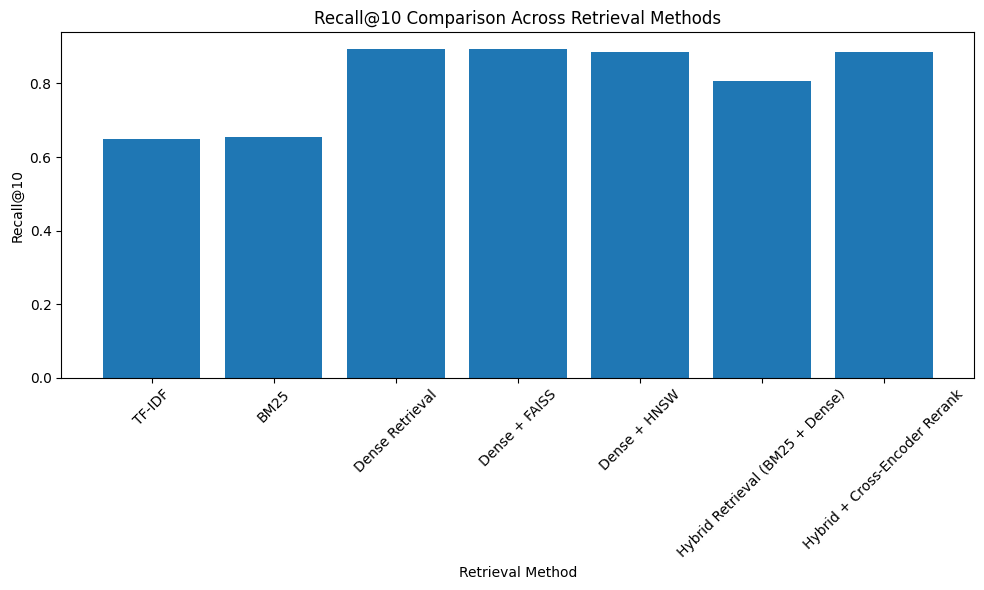

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(comparison_table["Method"], comparison_table["Recall@10"])

plt.xticks(rotation=45)
plt.ylabel("Recall@10")
plt.xlabel("Retrieval Method")
plt.title("Recall@10 Comparison Across Retrieval Methods")

plt.tight_layout()
plt.show()

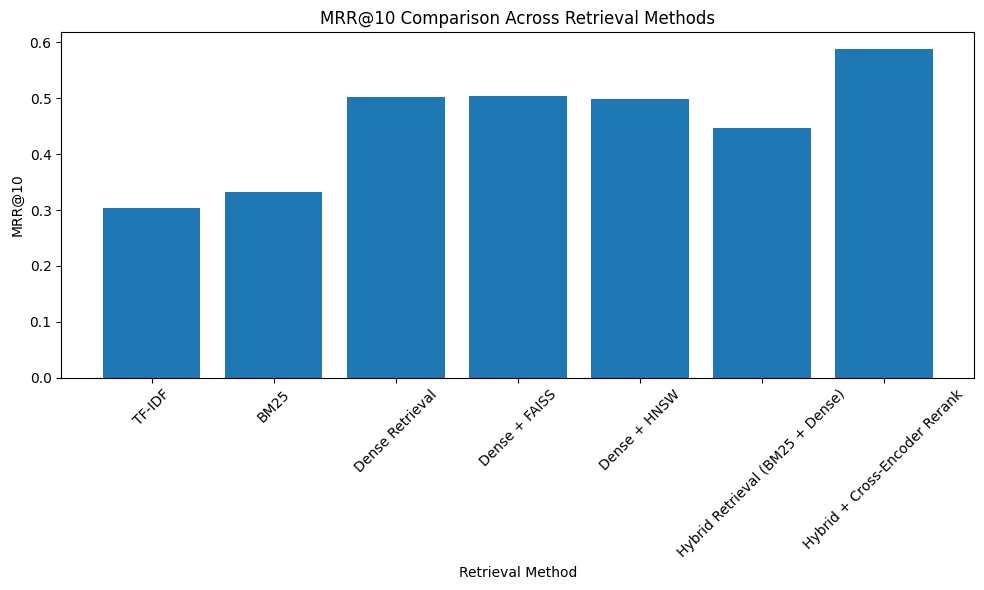

In [27]:
plt.figure(figsize=(10,6))

plt.bar(comparison_table["Method"], comparison_table["MRR@10"])

plt.xticks(rotation=45)
plt.ylabel("MRR@10")
plt.xlabel("Retrieval Method")
plt.title("MRR@10 Comparison Across Retrieval Methods")

plt.tight_layout()
plt.show()

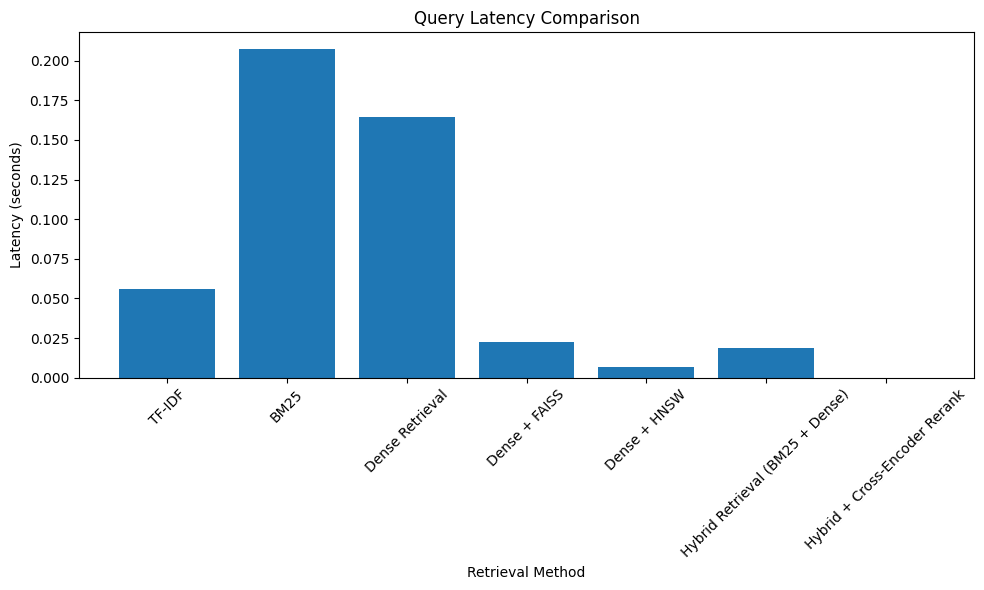

In [28]:
plt.figure(figsize=(10,6))

plt.bar(comparison_table["Method"], comparison_table["Avg Query Latency (s)"])

plt.xticks(rotation=45)
plt.ylabel("Latency (seconds)")
plt.xlabel("Retrieval Method")
plt.title("Query Latency Comparison")

plt.tight_layout()
plt.show()

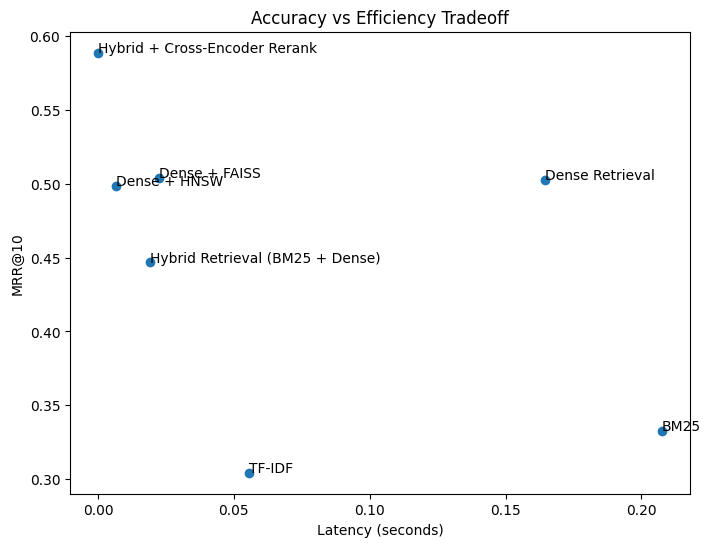

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(
    comparison_table["Avg Query Latency (s)"],
    comparison_table["MRR@10"]
)

for i, method in enumerate(comparison_table["Method"]):
    plt.text(
        comparison_table["Avg Query Latency (s)"][i],
        comparison_table["MRR@10"][i],
        method
    )

plt.xlabel("Latency (seconds)")
plt.ylabel("MRR@10")
plt.title("Accuracy vs Efficiency Tradeoff")

plt.show()